<a href="https://colab.research.google.com/github/agabrielabarros/Visualizacao_data_studio/blob/main/Analise_crimes_cibern%C3%A9ticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**ON40 PROJETO FINAL**

```
Tema: Análise de ataques cibernéticos globais e impacto financeiro (2015-2024)
Área: Segurança da Informação
```







## Importando a base de dados

> Base dados baixada em csv do google sheets para esse projeto: [Dados_ciber](https://docs.google.com/spreadsheets/d/1ZyZG_SykVvTF_20iFqLi6bcnyGtV97FZJtXCaDHjkFY/edit?usp=sharing)

> Fonte dos dados retiradas do Kaggle: [Cyber Attacks Dataset](https://https://www.kaggle.com/datasets/kavindutissera/cyber-attacks-dataset)

In [ ]:
import pandas as pd

In [ ]:
dados_ciber = pd.read_csv("/content/Base_dados_cibersegurança - Dados de ataques cibernéticos.csv")
dados_ciber

,ID_Ataque,Tipo_ataque,Industria_alvo,Localização,Data,Gravidade,Estimativa de danos (USD),Sistemas afetados,Unnamed: 8,Unnamed: 9
0,925,Privilege Escalation,Energia,Rússia,2015-01-01,Alto,2398227,547,NaN,NaN
1,1555,Malware,Governo,Japão,2015-01-01,Crítico,1169017,161,NaN,NaN
2,7594,Zero-day Exploit,Governo,Coreia do Sul,2015-01-01,Baixo,4477162,178,NaN,NaN
3,9001,Phishing,Varejo,Rússia,2015-01-01,Baixo,638892,988,NaN,NaN
4,4220,Zero-day Exploit,Varejo,Brasil,2015-01-03,Médio,1201371,97,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
9995,6739,Phishing,E-commerce,França,2024-12-30,Médio,4547990,793,NaN,NaN
9996,7164,Man-in-the-Middle,Governo,Alemanha,2024-12-30,Médio,4692517,294,NaN,NaN
9997,680,Injeção de SQL,Energia,Brasil,2024-12-31,Alto,4629640,318,NaN,NaN
9998,7104,Privilege Escalation,Financeiro,Alemanha,2024-12-31,Crítico,4053939,106,NaN,NaN


## Conhecendo e importando os dados


In [ ]:
dados_ciber.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID_Ataque                  10000 non-null  int64  
 1   Tipo_ataque                10000 non-null  object 
 2   Industria_alvo             10000 non-null  object 
 3   Localização                10000 non-null  object 
 4   Data                       10000 non-null  object 
 5   Gravidade                  10000 non-null  object 
 6   Estimativa de danos (USD)  10000 non-null  int64  
 7   Sistemas afetados          10000 non-null  int64  
 8   Unnamed: 8                 0 non-null      float64
 9   Unnamed: 9                 1 non-null      object 
dtypes: float64(1), int64(3), object(6)
memory usage: 781.4+ KB


Temos 10000 entradas que vão de 0 à 9999. Esta informação nos diz que não há nenhum índice saltado.

Temos o total de 10 colunas.

Na tabela propriamente dita, vemos quatro colunas com os seguintes dados:

* #, que possui o índice
* Column, com o nome da nossa coluna
* Non-Null Count, com a quantidade de valores não nulos
* DType, com o tipo do dado

Em Non-Null Count, percebemos que a maioria dos valores correspondem a 10000 (o número de amostras que temos). Contudo, alguns dados contém outros valores como, **0** e **1**, por exemplo a Unnamed:8 possui 0 amostras não nulas e a Unnamed:9 possui 1 amostra não nula amostras não nulas. Vamos tratá-las a seguir.

## Limpando e manipulando os dados

1º - Ao conhecer as informações na tabela entendemos que as colunas **8** e **9**, são colunas a mais na tabela. Vamos removê-las para começarmos a limpeza do nosso dataframe

In [ ]:
dados_ciber = dados_ciber.loc[:, ~dados_ciber.columns.str.contains("Unnamed")]


In [ ]:
dados_ciber.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   ID_Ataque                  10000 non-null  int64 
 1   Tipo_ataque                10000 non-null  object
 2   Industria_alvo             10000 non-null  object
 3   Localização                10000 non-null  object
 4   Data                       10000 non-null  object
 5   Gravidade                  10000 non-null  object
 6   Estimativa de danos (USD)  10000 non-null  int64 
 7   Sistemas afetados          10000 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 625.1+ KB


2º - Entendemos também que a coluna data está como tipo **object**, vamos atualizar para **datatime**

In [ ]:
dados_ciber["Data"] = pd.to_datetime(dados_ciber["Data"])

/tmp/ipython-input-3175175030.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_ciber["Data"] = pd.to_datetime(dados_ciber["Data"])


In [ ]:
dados_ciber.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   ID_Ataque                  10000 non-null  int64         
 1   Tipo_ataque                10000 non-null  object        
 2   Industria_alvo             10000 non-null  object        
 3   Localização                10000 non-null  object        
 4   Data                       10000 non-null  datetime64[ns]
 5   Gravidade                  10000 non-null  object        
 6   Estimativa de danos (USD)  10000 non-null  int64         
 7   Sistemas afetados          10000 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 625.1+ KB


3º - Para conseguirmos manipularmos melhor a coluna de **Estimativa de dados (USD)** vamos categorizar como tipo float:



In [ ]:
dados_ciber["Estimativa de danos (USD)"] = dados_ciber["Estimativa de danos (USD)"].astype(float)

/tmp/ipython-input-4005687441.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_ciber["Estimativa de danos (USD)"] = dados_ciber["Estimativa de danos (USD)"].astype(float)


In [ ]:
dados_ciber.dtypes

,0
ID_Ataque,int64
Tipo_ataque,object
Industria_alvo,object
Localização,object
Data,datetime64[ns]
Gravidade,object
Estimativa de danos (USD),float64
Sistemas afetados,int64


4º - Para conseguirmos manipularmos melhor a coluna de **Gravidade** vamos categorizar numéricamente onde:
* Crítico
* Alto
* Médio
* Baixo



In [ ]:
dados_ciber["Gravidade"] = dados_ciber["Gravidade"].astype("category")

/tmp/ipython-input-1453007481.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_ciber["Gravidade"] = dados_ciber["Gravidade"].astype("category")


In [ ]:
dados_ciber.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   ID_Ataque                  10000 non-null  int64         
 1   Tipo_ataque                10000 non-null  object        
 2   Industria_alvo             10000 non-null  object        
 3   Localização                10000 non-null  object        
 4   Data                       10000 non-null  datetime64[ns]
 5   Gravidade                  10000 non-null  category      
 6   Estimativa de danos (USD)  10000 non-null  float64       
 7   Sistemas afetados          10000 non-null  int64         
dtypes: category(1), datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 557.0+ KB


5º Vamos verificar para termos certeza se não existem valores faltantes

In [ ]:
dados_ciber.isnull().sum()


,0
ID_Ataque,0
Tipo_ataque,0
Industria_alvo,0
Localização,0
Data,0
Gravidade,0
Estimativa de danos (USD),0
Sistemas afetados,0


6º Vamos verificar para termos certeza se não existem valores duplicados

In [ ]:
dados_ciber.duplicated().sum()


np.int64(0)

## Explorando os primeiros dados

1º - Vamos criar uma nova coluna de **Ano**

In [ ]:
dados_ciber['Ano'] = dados_ciber['Data'].dt.year

/tmp/ipython-input-4144927814.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_ciber['Ano'] = dados_ciber['Data'].dt.year


In [ ]:
dados_ciber.drop(columns=['Ano'], inplace=True)
# Precisei apagar a coluna Ano que criei com o nome errado

/tmp/ipython-input-341838099.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_ciber.drop(columns=['Ano'], inplace=True)


In [ ]:
dados_ciber['Ano do Ataque'] = dados_ciber['Data'].dt.year
dados_ciber.head()


/tmp/ipython-input-39906677.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_ciber['Ano do Ataque'] = dados_ciber['Data'].dt.year


,ID_Ataque,Tipo_ataque,Industria_alvo,Localização,Data,Gravidade,Estimativa de danos (USD),Sistemas afetados,Ano do Ataque
0,925,Privilege Escalation,Energia,Rússia,2015-01-01,Alto,2398227.0,547,2015
1,1555,Malware,Governo,Japão,2015-01-01,Crítico,1169017.0,161,2015
2,7594,Zero-day Exploit,Governo,Coreia do Sul,2015-01-01,Baixo,4477162.0,178,2015
3,9001,Phishing,Varejo,Rússia,2015-01-01,Baixo,638892.0,988,2015
4,4220,Zero-day Exploit,Varejo,Brasil,2015-01-03,Médio,1201371.0,97,2015


2º - Vamos contar os ataques por tipo

In [ ]:
dados_ciber['Tipo_ataque'].value_counts()

,count
Tipo_ataque,
Privilege Escalation,1059
Phishing,1052
DDoS,1034
Malware,1022
Injeção de SQL,996
Zero-day Exploit,989
Cross-site Scripting (XSS),983
Ataque de força bruta,976
Man-in-the-Middle,955


3º Média de danos por tipo

In [ ]:
# calcular a média de danos por tipo de ataque, arredondar e transformar em DataFrame organizado
danos_por_tipo = (
    dados_ciber
    .groupby('Tipo_ataque')['Estimativa de danos (USD)']
    .mean()
    .round(2)                       # arredonda a média para 2 casas decimais
    .reset_index(name='Estimativa de danos (USD)')
    .sort_values(by='Estimativa de danos (USD)', ascending=False)
)
danos_por_tipo



,Tipo_ataque,Estimativa de danos (USD)
1,Cross-site Scripting (XSS),2568585.72
5,Man-in-the-Middle,2557421.19
2,DDoS,2541322.41
9,Zero-day Exploit,2531923.09
7,Privilege Escalation,2527446.76
8,Ransomware,2518445.56
4,Malware,2502561.26
6,Phishing,2480492.06
0,Ataque de força bruta,2464917.12
3,Injeção de SQL,2462450.02


In [ ]:
dados_ciber.groupby('Tipo_ataque')['Estimativa de danos (USD)'].mean().sort_values(ascending=False)


,Estimativa de danos (USD)
Tipo_ataque,
Cross-site Scripting (XSS),2.568586e+06
Man-in-the-Middle,2.557421e+06
DDoS,2.541322e+06
Zero-day Exploit,2.531923e+06
Privilege Escalation,2.527447e+06
Ransomware,2.518446e+06
Malware,2.502561e+06
Phishing,2.480492e+06
Ataque de força bruta,2.464917e+06


4º - Gravidade por indústria

In [ ]:
dados_ciber.groupby(['Industria_alvo', 'Gravidade']).size().unstack(fill_value=0)

/tmp/ipython-input-2822668501.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dados_ciber.groupby(['Industria_alvo', 'Gravidade']).size().unstack(fill_value=0)


Gravidade,Alto,Baixo,Crítico,Médio
Industria_alvo,,,,
Defesa,250,241,263,287
E-commerce,258,264,231,270
Educação,265,238,269,230
Energia,263,251,273,249
Financeiro,250,255,258,235
Governo,240,225,253,210
Saúde,277,260,265,246
Tecnologia,280,240,256,239
Telecomunicações,262,236,246,252


5º - Correlação entre danos e sistemas afetados

In [ ]:
dados_ciber[['Estimativa de danos (USD)', 'Sistemas afetados']].corr()


,Estimativa de danos (USD),Sistemas afetados
Estimativa de danos (USD),1.00000,0.00316
Sistemas afetados,0.00316,1.00000


0.00316 é praticamente ZERO
Isso significa que não existe relação linear entre:
Quantos sistemas foram afetados
O valor do dano financeiro

Ou seja:

* Ter mais sistemas afetados não aumenta os danos
* Ter poucos sistemas afetados não diminui os danos
* Os danos financeiros não dependem diretamente desse número

O número de sistemas atingidos não explica o tamanho do prejuízo.
Às vezes 2 sistemas afetados geram milhões de dólares em dano,
e outras vezes 20 sistemas afetados geram pouco prejuízo.

## Explorando os dados que queremos levar para Looker Studio

1. Contexto e Visão Global
* A quantidade de crimes cibernéticos ao longo dos anos
* Quais países são mais vulneráveis a ataques críticos?
* Onde o Brasil está na posição de maior quantidade de crimes cibernéticos cometidos?

2. Análise Detalhada
* Qual é a quantidade de ataques no Brasil e quão graves eles são?
* Quais são os nomes de ataques mais comuns no Brasil e qual o grau de gravidade?
* Qual a quantidade de ataques por setor?

3. Conclusão e Impacto
* Quanto por setor é o prejuízo em bilhões U$?

### 1. Contexto e Visão Global

In [ ]:
# A quantidade de crimes cibernéticos ao longo dos anos?
ataques_por_ano = dados_ciber.groupby('Ano do Ataque').size()
ataques_por_ano

,0
Ano do Ataque,
2015,1016
2016,1040
2017,996
2018,956
2019,1048
2020,1010
2021,974
2022,999
2023,1005


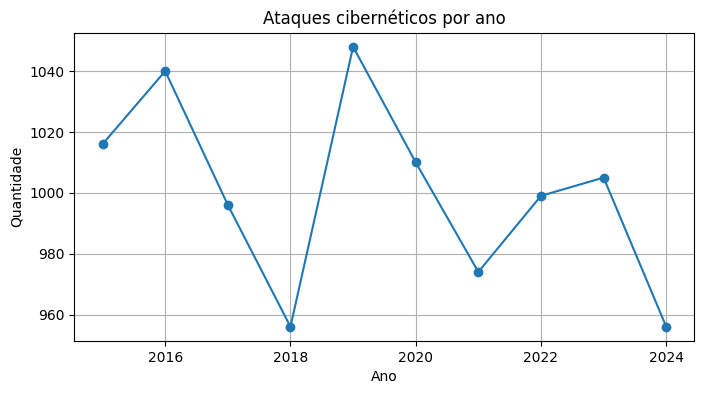

In [ ]:
import matplotlib.pyplot as plt
ataques_por_ano.plot(kind='line', marker='o', figsize=(8,4))
plt.title("Ataques cibernéticos por ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade")
plt.grid(True)
plt.show()

In [ ]:
#Quais países são mais vulneráveis a ataques críticos?
criticos = dados_ciber[dados_ciber['Gravidade'] == 'Crítico']
criticos

,ID_Ataque,Tipo_ataque,Industria_alvo,Localização,Data,Gravidade,Estimativa de danos (USD),Sistemas afetados,Ano do Ataque
1,1555,Malware,Governo,Japão,2015-01-01,Crítico,1169017.0,161,2015
8,6559,Zero-day Exploit,Educação,Alemanha,2015-01-04,Crítico,4326460.0,105,2015
11,1070,Injeção de SQL,Tecnologia,Índia,2015-01-05,Crítico,4251404.0,69,2015
18,4228,Ataque de força bruta,Varejo,EUA,2015-01-06,Crítico,785984.0,84,2015
21,430,Ransomware,Telecomunicações,EUA,2015-01-07,Crítico,1084108.0,675,2015
...,...,...,...,...,...,...,...,...,...
9984,4008,Ataque de força bruta,Defesa,EUA,2024-12-25,Crítico,3216768.0,525,2024
9985,9359,Malware,Energia,Brasil,2024-12-25,Crítico,4880357.0,21,2024
9990,7419,Cross-site Scripting (XSS),E-commerce,Alemanha,2024-12-29,Crítico,4900666.0,123,2024
9994,6532,Cross-site Scripting (XSS),Governo,Reino Unido,2024-12-30,Crítico,734068.0,964,2024


In [ ]:
criticos_por_pais = criticos['Localização'].value_counts()
criticos_por_pais.head(5)

,count
Localização,
Índia,277
Japão,262
Rússia,262
China,261
França,257


In [ ]:
# Onde o Brasil está na posição de maior quantidade de crimes cibernéticos cometidos?

ataques_por_pais = dados_ciber['Localização'].value_counts()
ataques_por_pais

,count
Localização,
China,1072
Índia,1048
Rússia,1025
França,1019
Coreia do Sul,1006
Reino Unido,987
Japão,977
EUA,973
Alemanha,947


In [ ]:
posicao_brasil = ataques_por_pais.index.get_loc("Brasil") + 1
print(f"O Brasil está na posição {posicao_brasil} no ranking de países com mais ataques.")


O Brasil está na posição 10 no ranking de países com mais ataques.


O que esse código faz:
- Conta quantos ataques cada país teve
- Ordena automaticamente do maior para o menor
- Descobre a posição do Brasil nessa lista
- Mostra o ranking fin

###2. Análise Detalhada

In [ ]:
# Quantidade de ataques no Brasil e quão graves eles são ?
brasil = dados_ciber[dados_ciber['Localização'] == 'Brasil']


In [ ]:
total_brasil = len(brasil)
print("Total de ataques no Brasil:", total_brasil)

Total de ataques no Brasil: 946


In [ ]:
gravidade_brasil = brasil['Gravidade'].value_counts()
print("\nGravidade dos ataques no Brasil:")
print(gravidade_brasil)



Gravidade dos ataques no Brasil:
Gravidade
Alto       258
Baixo      245
Crítico    232
Médio      211
Name: count, dtype: int64


O que nosso código faz:
- Filtra somente as linhas onde a localização é “Brasil”
- Conta quantos ataques aconteceram no Brasil
- Mostra como esses ataques se distribuem pela gravidade,

In [ ]:
# Quais são os nomes de ataques mais comuns no Brasil e qual o grau de gravidade?
ataques_brasil = brasil.groupby(['Tipo_ataque', 'Gravidade']).size().reset_index(name='Quantidade')
ataques_brasil = ataques_brasil.sort_values(by='Quantidade', ascending=False)


/tmp/ipython-input-318345284.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ataques_brasil = brasil.groupby(['Tipo_ataque', 'Gravidade']).size().reset_index(name='Quantidade')


In [ ]:
ataques_brasil.head(11)


,Tipo_ataque,Gravidade,Quantidade
8,DDoS,Alto,35
4,Cross-site Scripting (XSS),Alto,33
22,Man-in-the-Middle,Crítico,33
16,Malware,Alto,29
18,Malware,Crítico,29
1,Ataque de força bruta,Baixo,28
14,Injeção de SQL,Crítico,28
17,Malware,Baixo,28
31,Privilege Escalation,Médio,27
3,Ataque de força bruta,Médio,27


O que nosso código faz:
- Os tipos de ataque mais comuns no Brasil
- Junto com o respectivo grau de gravidade
- Ordenados do mais frequente para o menos frequente


In [ ]:
#Qual a quantidade de ataques por setor?
crimes_por_setor = dados_ciber['Industria_alvo'].value_counts()
crimes_por_setor



,count
Industria_alvo,
Saúde,1048
Defesa,1041
Energia,1036
E-commerce,1023
Tecnologia,1015
Educação,1002
Financeiro,998
Telecomunicações,996
Governo,928


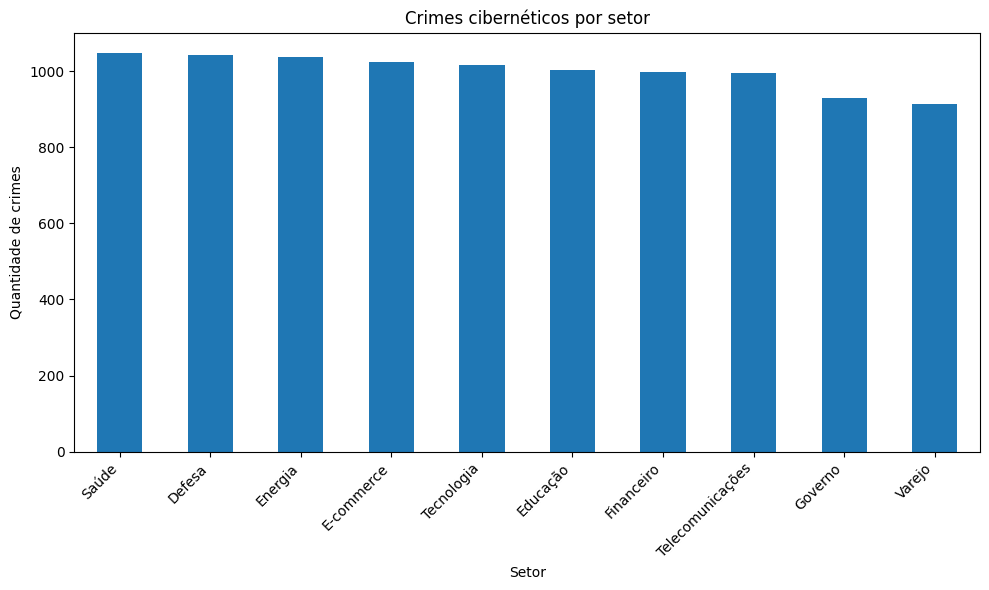

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
crimes_por_setor.plot(kind='bar')
plt.xlabel("Setor")
plt.ylabel("Quantidade de crimes")
plt.title("Crimes cibernéticos por setor")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###3. Conclusão e Impacto

In [ ]:
#Quanto por setor é o prejuízo em bilhões U$?
prejuizo_por_setor = dados_ciber.groupby('Industria_alvo')['Estimativa de danos (USD)'].sum().reset_index()
prejuizo_por_setor


,Industria_alvo,Estimativa de danos (USD)
0,Defesa,2.671618e+09
1,E-commerce,2.577623e+09
2,Educação,2.594409e+09
3,Energia,2.562903e+09
4,Financeiro,2.523995e+09
5,Governo,2.339805e+09
6,Saúde,2.567854e+09
7,Tecnologia,2.576674e+09
8,Telecomunicações,2.507669e+09
9,Varejo,2.230756e+09


### Baixarmos os dados em csv

In [ ]:
dados_ciber.to_csv('dados_ciber_tratados.csv', index=False)
print('Arquivo dados_ciber_tratados.csv salvo com sucesso! Você pode baixá-lo no painel de arquivos à esquerda.')

Arquivo dados_ciber_tratados.csv salvo com sucesso! Você pode baixá-lo no painel de arquivos à esquerda.
